In [1]:
# Data preprocessing in python for machine learning

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')
planes_df = pd.read_csv('Data/planes_crashes.csv')
planes_df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [3]:
print(planes_df.isna().sum())

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64


In [4]:
print(planes_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5268 non-null   object 
 1   Time          3049 non-null   object 
 2   Location      5248 non-null   object 
 3   Operator      5250 non-null   object 
 4   Flight #      1069 non-null   object 
 5   Route         3561 non-null   object 
 6   Type          5241 non-null   object 
 7   Registration  4933 non-null   object 
 8   cn/In         4040 non-null   object 
 9   Aboard        5246 non-null   float64
 10  Fatalities    5256 non-null   float64
 11  Ground        5246 non-null   float64
 12  Summary       4878 non-null   object 
dtypes: float64(3), object(10)
memory usage: 535.2+ KB
None


In [9]:
planes_df["Date"] = pd.to_datetime(planes_df["Date"])

In [5]:
# Drop the cn/In and Route columns from planes_df (less useful for most analysis)
planes_cols = planes_df.drop(["cn/In", "Route"], axis=1)

# Drop rows with missing Fatalities values from planes_cols
planes_subset = planes_cols.dropna(subset=["Fatalities"])

# Print out the shape of the subset
print(planes_subset.shape)

(5256, 11)


In [6]:
print(planes_subset.isna().sum())

Date               0
Time            2207
Location          19
Operator          18
Flight #        4187
Type              25
Registration     334
Aboard            10
Fatalities         0
Ground            10
Summary          385
dtype: int64


In [15]:
planes_df['Operator'].dropna()

0                  Military - U.S. Army
1                  Military - U.S. Navy
2                               Private
3                Military - German Navy
4                Military - German Navy
                     ...               
5263    Military - Indonesian Air Force
5264                        Service Air
5265                         Air France
5266                         Strait Air
5267        Military - Indian Air Force
Name: Operator, Length: 5250, dtype: object

In [17]:
# Drop rows with missing Operator (can't train/predict a missing label)
planes_df = planes_df.dropna(subset=['Operator'])

# Keep only operators with at least 2 occurrences (required for stratified split)
operator_counts = planes_df['Operator'].value_counts()
valid_operators = operator_counts[operator_counts >= 2].index
planes_df = planes_df[planes_df['Operator'].isin(valid_operators)]

# Create a DataFrame with all columns except Operator
X = planes_df.drop("Operator", axis=1)

# Create an Operator labels dataset
y = planes_df[['Operator']]

# Use stratified sampling to split up the dataset according to the y dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Print the Operator counts from y_train
print(y_train['Operator'].value_counts())

Operator
Aeroflot                             134
Military - U.S. Air Force            132
Air France                            52
Deutsche Lufthansa                    49
Air Taxi                              33
                                    ... 
Saturn Airways                         1
Salair                                 1
Crossair                               1
Channel Flying Service - Air Taxi      1
Military - Colombian Army              1
Name: count, Length: 555, dtype: int64


In [18]:
import numpy as np
import statsmodels.api as sm

# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

# Add constant for intercept term
X = sm.add_constant(x)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     4.500
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.124
Time:                        09:52:48   Log-Likelihood:                -5.2598
No. Observations:                   5   AIC:                             14.52
Df Residuals:                       3   BIC:                             13.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2000      0.938      2.345      0.1

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [19]:
import numpy as np

# Sample data
x = np.array([1, 2, 3, 4, 5])  # Independent variable
y = np.array([2, 4, 5, 4, 5])  # Dependent variable

correlation = np.corrcoef(x, y)[0, 1]
print("Correlation:", correlation)

Correlation: 0.7745966692414834


In [20]:
beta_1 = correlation * (np.std(y) / np.std(x))

In [21]:
beta_0 = np.mean(y) - beta_1 * np.mean(x)

In [23]:
y_pred = beta_0 + beta_1 * x

import 

[2.8 3.4 4.  4.6 5.2]


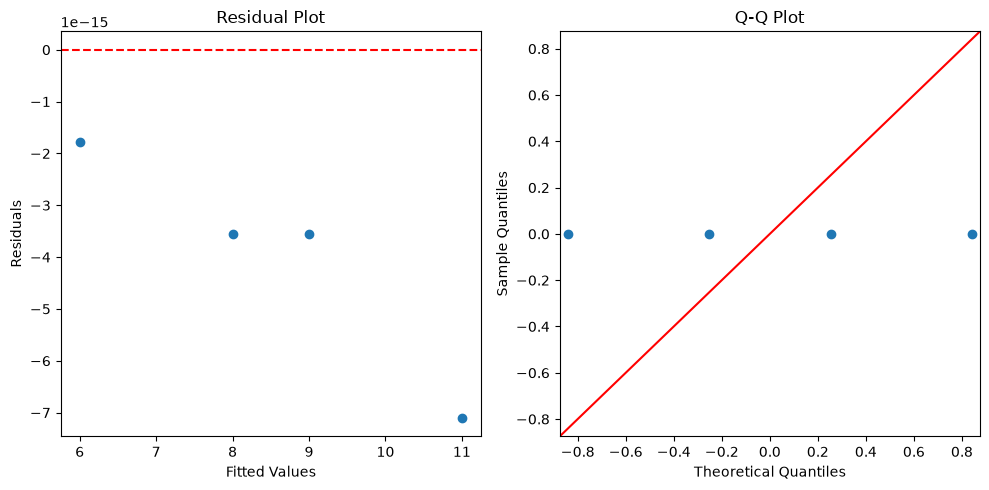

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Sample data and linear regression model
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])  # Independent variables
y = np.array([6, 8, 9, 11])  # Dependent variable

# Add an intercept term
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Get the residuals
residuals = model.resid

# 1. Residual Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line ='45', ax=plt.gca())
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()